In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_wine


=========== DATASET IRIS ===========

--- Comparação de Topologias ---
Rectangular → QE: 0.3285 | TE: 0.0067
Hexagonal   → QE: 0.3467 | TE: 0.0533

--- Teste de Diferentes Eta e Sigma ---
eta=0.1 | sigma=1 → QE=0.3250 | TE=0.6000
eta=0.5 | sigma=3 → QE=0.3467 | TE=0.0533
eta=0.8 | sigma=5 → QE=0.4795 | TE=0.0733
eta=0.05 | sigma=10 → QE=0.7967 | TE=0.1600

=========== DATASET WINE ===========
Wine Dataset → QE: 1.6916 | TE: 0.0337


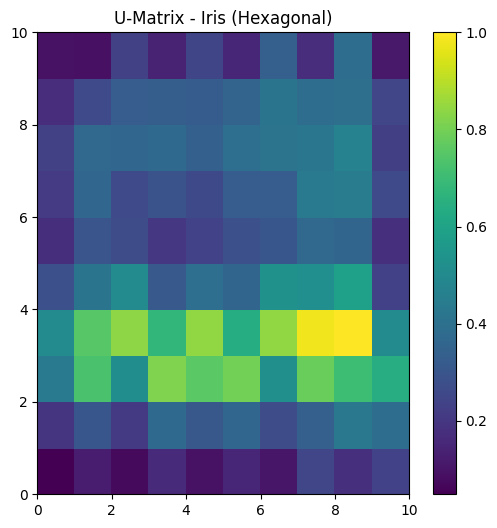

In [5]:
# FUNÇÃO DE TREINAMENTO

def treinar_som(X, neuD1, neuD2, sigma, eta, topology):

    som = MiniSom(neuD1, neuD2, X.shape[1],
                  sigma=sigma,
                  learning_rate=eta,
                  neighborhood_function='gaussian',
                  topology=topology,
                  random_seed=42)

    som.random_weights_init(X)
    som.train_random(X, 1000)

    qe = som.quantization_error(X)
    te = som.topographic_error(X)

    return som, qe, te

# DATASET IRIS

print("\n=========== DATASET IRIS ===========")

iris = load_iris()
X = iris.data

scaler = StandardScaler()
X = scaler.fit_transform(X)

# TESTE DE TOPOLOGIAS
print("\n--- Comparação de Topologias ---")

som_rect, qe_rect, te_rect = treinar_som(X, 10, 10, 3, 0.5, 'rectangular')
som_hex, qe_hex, te_hex = treinar_som(X, 10, 10, 3, 0.5, 'hexagonal')

print(f"Rectangular → QE: {qe_rect:.4f} | TE: {te_rect:.4f}")
print(f"Hexagonal   → QE: {qe_hex:.4f} | TE: {te_hex:.4f}")

# TESTE DE ETA E SIGMA

print("\n--- Teste de Diferentes Eta e Sigma ---")

experimentos = [
    (0.1, 1),
    (0.5, 3),
    (0.8, 5),
    (0.05, 10)
]

for eta, sigma in experimentos:
    som, qe, te = treinar_som(X, 10, 10, sigma, eta, 'hexagonal')
    print(f"eta={eta} | sigma={sigma} → QE={qe:.4f} | TE={te:.4f}")

# OUTRO DATASET (WINE)

print("\n=========== DATASET WINE ===========")

wine = load_wine()
X_wine = wine.data
X_wine = scaler.fit_transform(X_wine)

som_wine, qe_wine, te_wine = treinar_som(X_wine, 12, 12, 3, 0.5, 'hexagonal')

print(f"Wine Dataset → QE: {qe_wine:.4f} | TE: {te_wine:.4f}")

# VISUALIZAÇÃO U-MATRIX

plt.figure(figsize=(6, 6))
plt.title("U-Matrix - Iris (Hexagonal)")
plt.pcolor(som_hex.distance_map())
plt.colorbar()
plt.show()